Here, we compare Logistic Regression, XGBoost, SVC, and RandomForest's performance via nestedCV.

# Imports

In [36]:
import pandas as pd
import numpy as np

# Get and Format Data

In [37]:
def prepare_data(data, year):
    data = data.rename(columns=lambda x: x[2:] if x[1]=='_' else x)
    data['year'] = year
    data = data.sample(frac=1)
    return data

In [ ]:
amazon_train_sets = [prepare_data(pd.read_csv(f"datasets/post_pivot/plus_one/expanded_class/training/amazon_train_{year}_year_expanded_class.csv"), year) for year in range(2022, 2025)]
amazon_train = pd.concat(amazon_train_sets, axis=0)

taiga_train_sets = [prepare_data(pd.read_csv(f"datasets/post_pivot/plus_one/expanded_class/training/taiga_train_{year}_year_expanded_class.csv"), year) for year in range(2022, 2025)]
taiga_train = pd.concat(taiga_train_sets, axis=0)

borneo_train_sets = [prepare_data(pd.read_csv(f"datasets/post_pivot/plus_one/expanded_class/training/borneo_train_{year}_year_expanded_class.csv"), year) for year in range(2022, 2025)]
borneo_train = pd.concat(borneo_train_sets, axis=0)

train_set = pd.concat([amazon_train, taiga_train, borneo_train], axis=0)
train_set = train_set.sample(frac=1)
train_set = train_set.sort_values(by='year')
print(train_set.head())
# print(train_set.groupby('year')['class'].count())

     system:index  NBR_delta_lag4  NBR_lag4  NDMI_delta_lag4  NDMI_lag4  \
1114     1_4114_0        0.154969  0.207929         0.084427   0.100142   
175      1_3176_0        0.077044  0.344993         0.038037   0.204709   
5787     2_2823_0       -0.002400  0.353838        -0.015291   0.208682   
546      1_3554_0        0.132181  0.383834         0.151947   0.239461   
5315     2_2405_0       -0.032233  0.366546        -0.008835   0.252171   

      NDVI_delta_lag4  NDVI_lag4  SR_B4_delta_lag4  SR_B4_lag4  \
1114         0.046157   0.218325            1320.5      9559.5   
175          0.126958   0.387652            -907.0      8331.0   
5787         0.004341   0.414082              48.0      8180.0   
546          0.120843   0.449544            -662.0      8564.0   
5315        -0.007495   0.440374             235.5      8318.0   

      SR_B5_delta_lag4  ...  NDVI_lag0  SR_B4_lag0  SR_B5_lag0  SR_B6_lag0  \
1114            3233.5  ...   0.172168      8239.0     11666.0     11305.0

In [39]:
print(amazon_train[['NBR_lag4', 'NBR_delta_lag4', 'NBR_lag0']].head())

      NBR_lag4  NBR_delta_lag4  NBR_lag0
3335  0.396031        0.014750  0.381281
221   0.318256        0.146240  0.172016
2659  0.320124        0.106600  0.213524
1613  0.362598        0.042710  0.319888
2963  0.282044        0.049327  0.232717


# Feature Selection

In [40]:
# select all feature columns except metadata/target columns
exclude_cols = {'index', 'system:index', 'class', 'latitude', 'longitude', '.geo', 'year'}
all_features = [c for c in train_set.columns if c not in exclude_cols]
# drop columns ending with "delta_lag1"
# drop_cols = [c for c in train_set.columns if c.endswith('delta_lag1')]
# train_set = train_set.drop(columns=drop_cols)
# all_features = [c for c in all_features if c not in drop_cols]
# print(f"Dropped {len(drop_cols)} columns: {drop_cols}")

recent_features = ['NBR_delta_lag1', 'NBR_lag1',
       'NDMI_delta_lag1', 'NDMI_lag1', 'NDVI_delta_lag1', 'NDVI_lag1',
       'SR_B4_delta_lag1', 'SR_B4_lag1', 'SR_B5_delta_lag1', 'SR_B5_lag1',
       'SR_B6_delta_lag1', 'SR_B6_lag1', 'SR_B7_delta_lag1', 'SR_B7_lag1',
       'NBR_lag0', 'NDMI_lag0', 'NDVI_lag0', 'SR_B4_lag0', 'SR_B5_lag0',
       'SR_B6_lag0', 'SR_B7_lag0']

In [41]:
X_train = train_set[recent_features]
y_train = train_set['class']
print(X_train.columns)

Index(['NBR_delta_lag1', 'NBR_lag1', 'NDMI_delta_lag1', 'NDMI_lag1',
       'NDVI_delta_lag1', 'NDVI_lag1', 'SR_B4_delta_lag1', 'SR_B4_lag1',
       'SR_B5_delta_lag1', 'SR_B5_lag1', 'SR_B6_delta_lag1', 'SR_B6_lag1',
       'SR_B7_delta_lag1', 'SR_B7_lag1', 'NBR_lag0', 'NDMI_lag0', 'NDVI_lag0',
       'SR_B4_lag0', 'SR_B5_lag0', 'SR_B6_lag0', 'SR_B7_lag0'],
      dtype='object')


class               1.000000
NDMI_delta_lag1     0.527731
NBR_delta_lag1      0.504278
NDVI_delta_lag1     0.480199
NDMI_lag0           0.441196
NBR_lag0            0.414164
SR_B7_delta_lag1    0.410557
SR_B6_delta_lag1    0.389458
SR_B5_delta_lag1    0.373656
NDVI_lag0           0.356859
SR_B7_lag0          0.349987
SR_B6_lag0          0.328475
SR_B4_delta_lag1    0.321991
SR_B4_lag0          0.285583
SR_B5_lag0          0.239624
SR_B5_lag1          0.092621
NDVI_lag1           0.090465
NBR_lag1            0.058576
SR_B6_lag1          0.034124
NDMI_lag1           0.034052
SR_B4_lag1          0.031060
SR_B7_lag1          0.004634
Name: class, dtype: float64


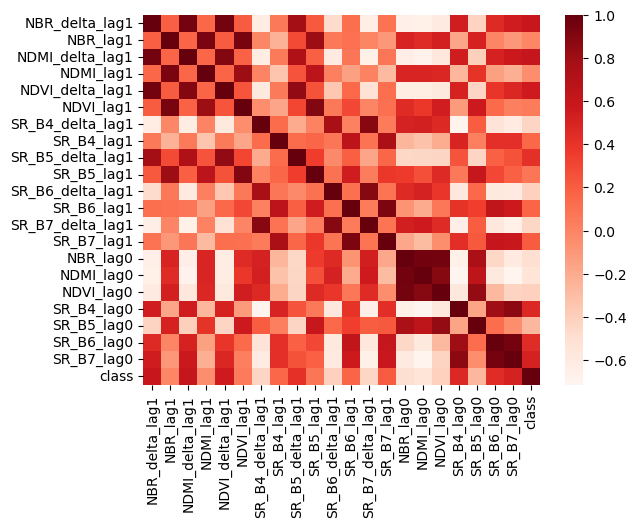

In [42]:
import seaborn as sns
sns.heatmap(pd.concat([amazon_train[recent_features], amazon_train['class']], axis=1).corr(method='spearman'), cmap='Reds')
print(abs(pd.concat([amazon_train[recent_features], amazon_train['class']], axis=1).corr()['class']).sort_values(ascending=False))

Features not well correlated...

# Compare Models

In [34]:
def custom_year_ts_split(df, year_col):
    """Custom CV splitter for our yearly data."""
    # Get unique years and sort them
    years = sorted(df[year_col].unique())
    
    # We need at least 2 years to do one split (Train Y1 -> Val Y2)
    for i in range(1, len(years)):
        # Training set: All years up to the current split
        train_indices = df[df[year_col].isin(years[:i])].index.values
        
        # Validation set: The very next year
        val_indices = df[df[year_col] == years[i]].index.values
        yield train_indices, val_indices

In [58]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PowerTransformer, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_validate


In [43]:
from skopt import BayesSearchCV
from skopt.space import Real, Categorical, Integer
from xgboost import XGBClassifier

## Logistic Regression

In [56]:
logistic_param_grid = {
    'model__l1_ratio': Real(0, 1),
    'model__C': Real(0.01, 10),
    'model__fit_intercept': Categorical([True, False]),
}

In [60]:

cv_iterator = custom_year_ts_split(train_set, 'year')
logistic_pipe = Pipeline([
    ('transformer', PowerTransformer('yeo-johnson')),
    ('model', LogisticRegression(
        penalty='elasticnet',
        max_iter=5000,
        warm_start=True,
        tol=1e-3,
        solver='saga',
        random_state=1,
    ))])

tuner = BayesSearchCV(
    estimator=logistic_pipe,
    cv=5,
    n_iter=32,
    refit='f1',
    search_spaces=logistic_param_grid,
    return_train_score=True,
    random_state=1,
    scoring='f1',
)

cv_iterator = custom_year_ts_split(train_set, 'year')


logistic_results = cross_validate(
    tuner, 
    X_train, 
    y_train, 
    cv=cv_iterator, 
    return_estimator=True,
    scoring=['f1', 'precision', 'recall'], 
    return_train_score=True,  # Crucial for detecting overfitting
    verbose=10,
)

[CV] START .....................................................................


/opt/anaconda3/envs/deforestationenv/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/opt/anaconda3/envs/deforestationenv/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/opt/anaconda3/envs/deforestationenv/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8

[CV] END  f1: (train=0.811, test=0.811) precision: (train=0.865, test=0.865) recall: (train=0.764, test=0.764) total time= 4.7min
[CV] START .....................................................................


[Parallel(n_jobs=1)]: Done   1 tasks      | elapsed:  4.7min
/opt/anaconda3/envs/deforestationenv/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/opt/anaconda3/envs/deforestationenv/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/opt/anaconda3/envs/deforestationenv/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py

[CV] END  f1: (train=0.812, test=0.812) precision: (train=0.864, test=0.864) recall: (train=0.766, test=0.766) total time= 7.2min


[Parallel(n_jobs=1)]: Done   2 out of   2 | elapsed: 11.9min finished


In [61]:
print(f"Mean Test f1: {logistic_results['test_f1'].mean():.4f}")
print(f"Mean Test Precision: {logistic_results['test_precision'].mean():.4f}")
print(f"Mean Test Recall: {logistic_results['test_recall'].mean():.4f}")

print(f"Mean Train f1: {logistic_results['train_f1'].mean():.4f}")
print(f"Mean Train Precision: {logistic_results['train_precision'].mean():.4f}")
print(f"Mean Train Recall: {logistic_results['train_recall'].mean():.4f}")

print(f"Overfitting Ratio: {1-logistic_results['test_f1'].mean()/logistic_results['train_f1'].mean()}")

Mean Test f1: 0.8116
Mean Test Precision: 0.8646
Mean Test Recall: 0.7648
Mean Train f1: 0.8116
Mean Train Precision: 0.8647
Mean Train Recall: 0.7647
Overfitting Ratio: -1.4556331928705646e-06


Logistic Regression exhibits decent f1 scores.

## XGBoost

In [44]:
xgboost_param_grid = {
    'model__max_depth': Integer(3, 5),
    'model__min_child_weight': Integer(1, 200),
    'model__subsample': Real(0.7, 1),
    'model__colsample_bylevel': Real(0.5, 1),
    'model__colsample_bynode': Real(0.5, 1),
    'model__reg_lambda': Real(0, 10),
    'model__reg_alpha': Real(0, 10)
}

In [ ]:
xgb_pipe = Pipeline([
    ('transformer', PowerTransformer('yeo-johnson')),
    ('model', XGBClassifier(objective='binary:logistic', random_state=1, learning_rate=0.3, tree_method='hist'))
])

tuner = BayesSearchCV(
    estimator=xgb_pipe,
    cv=5,
    n_iter=32,
    refit='f1',
    search_spaces=xgboost_param_grid,
    return_train_score=True,
    random_state=1,
    scoring='f1',
)

cv_iterator = custom_year_ts_split(train_set, 'year')

xgb_results = cross_validate(
    tuner,
    X_train, 
    y_train, 
    cv=cv_iterator, 
    scoring=['f1', 'precision', 'recall'], 
    return_estimator=True,
    return_train_score=True  # Crucial for detecting overfitting
)

In [46]:
# Print inner-CV (5-fold) average train/test scores for each outer fold (using best inner params)
for outer_fold, outer_estimator in enumerate(xgb_results['estimator'], start=1):
    search = outer_estimator.named_steps['model'] if hasattr(outer_estimator, "named_steps") else outer_estimator
    inner_results = pd.DataFrame(search.cv_results_)
    best_idx = search.best_index_

    print(f"Outer Fold {outer_fold} Parameters - {search.best_params_}")
    mean_test = inner_results.loc[best_idx, "mean_test_score"]
    std_test = inner_results.loc[best_idx, "std_test_score"]
    print(f"Outer Fold {outer_fold} - Inner Mean Test Score:  {mean_test:.6f}")
    print(f"Outer Fold {outer_fold} - Inner Test Score STD:  {std_test:.6f}")

    if "mean_train_score" in inner_results.columns:
        mean_train = inner_results.loc[best_idx, "mean_train_score"]
        std_train = inner_results.loc[best_idx, "std_train_score"]
        print(f"Outer Fold {outer_fold} - Inner Mean Train Score: {mean_train:.6f}")
        print(f"Outer Fold {outer_fold} - Inner Train Score STD:  {std_test:.6f}")
    else:
        print(f"Outer Fold {outer_fold} - Inner Mean Train Score: not available (set return_train_score=True in BayesSearchCV)")

print('\nOverall Metrics')
print(f"Mean Test f1: {xgb_results['test_f1'].mean():.8f}")
print(f"Mean Test Precision: {xgb_results['test_precision'].mean():.8f}")
print(f"Mean Test Recall: {xgb_results['test_recall'].mean():.8f}")

print(f"Mean Train f1: {xgb_results['train_f1'].mean():.8f}")
print(f"Mean Train Precision: {xgb_results['train_precision'].mean():.8f}")
print(f"Mean Train Recall: {xgb_results['train_recall'].mean():.8f}")

print(f"Overfitting Ratio: {1-xgb_results['test_f1'].mean()/xgb_results['train_f1'].mean()}")

Outer Fold 1 Parameters - OrderedDict({'model__colsample_bylevel': 1.0, 'model__colsample_bynode': 1.0, 'model__max_depth': 5, 'model__min_child_weight': 1, 'model__reg_alpha': 0.0, 'model__reg_lambda': 0.0, 'model__subsample': 0.7})
Outer Fold 1 - Inner Mean Test Score:  0.971604
Outer Fold 1 - Inner Test Score STD:  0.001589
Outer Fold 1 - Inner Mean Train Score: 0.992579
Outer Fold 1 - Inner Train Score STD:  0.001589
Outer Fold 2 Parameters - OrderedDict({'model__colsample_bylevel': 1.0, 'model__colsample_bynode': 1.0, 'model__max_depth': 5, 'model__min_child_weight': 1, 'model__reg_alpha': 0.0, 'model__reg_lambda': 0.0, 'model__subsample': 1.0})
Outer Fold 2 - Inner Mean Test Score:  0.987019
Outer Fold 2 - Inner Test Score STD:  0.002497
Outer Fold 2 - Inner Mean Train Score: 0.992110
Outer Fold 2 - Inner Train Score STD:  0.002497

Overall Metrics
Mean Test f1: 0.99318101
Mean Test Precision: 0.99667705
Mean Test Recall: 0.98970942
Mean Train f1: 0.99319937
Mean Train Precision:

XGBoost outperforms Logistic Regression and SVC with incredible scores.

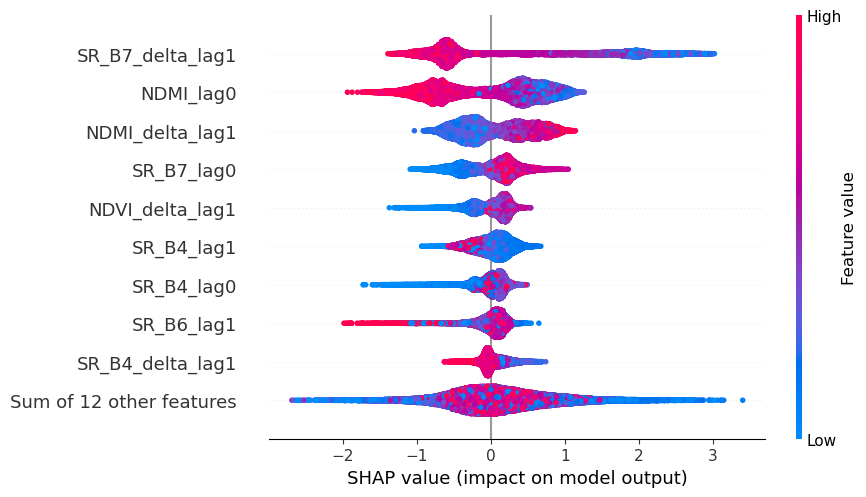

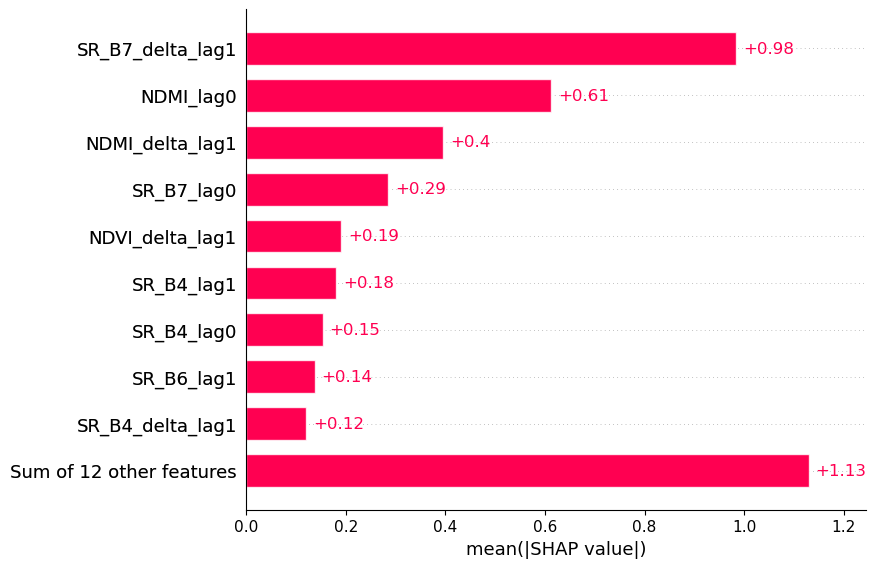

In [64]:
import shap
# Re-fit the tuner on full training data to get a final best estimator for interpretation
tuner.fit(X_train, y_train)
best_pipe = tuner.best_estimator_
model = best_pipe.named_steps['model']
explainer = shap.Explainer(model)
# Transform training data for the model component
X_trans = pd.DataFrame(
    best_pipe.named_steps['transformer'].transform(X_train),
    columns=recent_features,
    index=X_train.index,
)
shap_values = explainer(X_trans)
# visualize explanations
shap.plots.beeswarm(shap_values)
shap.plots.bar(shap_values)


## SVC

In [48]:
from sklearn.svm import SVC

In [49]:
svc_param_grid = {
    'model__C': Real(0.1, 10),
    'model__kernel': Categorical(['linear', 'poly', 'rbf'])
}

In [50]:
svc_pipe = Pipeline([
    ('transformer', PowerTransformer('yeo-johnson')),
    ('model', SVC(random_state=1))])

tuner = BayesSearchCV(
    estimator=svc_pipe,
    cv=5,
    n_iter=32,
    search_spaces=svc_param_grid,
    return_train_score=True,
    random_state=1,
    scoring='f1'
)

cv_iterator = custom_year_ts_split(train_set, 'year')

svc_results = cross_validate(
    tuner,
    X_train, 
    y_train, 
    cv=cv_iterator, 
    scoring=['f1', 'precision', 'recall'], 
    return_estimator=True,
    return_train_score=True  # Crucial for detecting overfitting
)

In [51]:
# Print inner-CV (5-fold) average train/test scores for each outer fold (using best inner params)
for outer_fold, outer_estimator in enumerate(svc_results['estimator'], start=1):
    search = outer_estimator.named_steps['model'] if hasattr(outer_estimator, "named_steps") else outer_estimator
    inner_results = pd.DataFrame(search.cv_results_)
    best_idx = search.best_index_
    print(f"Outer Fold {outer_fold} Parameters - {search.best_params_}")
    mean_test = inner_results.loc[best_idx, "mean_test_score"]
    std_test = inner_results.loc[best_idx, "std_test_score"]
    print(f"Outer Fold {outer_fold} - Inner Mean Test Score:  {mean_test:.6f}")
    print(f"Outer Fold {outer_fold} - Inner Test Score STD:  {std_test:.6f}")

    if "mean_train_score" in inner_results.columns:
        mean_train = inner_results.loc[best_idx, "mean_train_score"]
        std_train = inner_results.loc[best_idx, "std_train_score"]
        print(f"Outer Fold {outer_fold} - Inner Mean Train Score: {mean_train:.6f}")
        print(f"Outer Fold {outer_fold} - Inner Train Score STD:  {std_test:.6f}")
    else:
        print(f"Outer Fold {outer_fold} - Inner Mean Train Score: not available (set return_train_score=True in BayesSearchCV)")

print('\nOverall Metrics')
print(f"Mean Test f1: {svc_results['test_f1'].mean():.8f}")
print(f"Mean Test Precision: {svc_results['test_precision'].mean():.8f}")
print(f"Mean Test Recall: {svc_results['test_recall'].mean():.8f}")

print(f"Mean Train f1: {svc_results['train_f1'].mean():.8f}")
print(f"Mean Train Precision: {svc_results['train_precision'].mean():.8f}")
print(f"Mean Train Recall: {svc_results['train_recall'].mean():.8f}")

print(f"Overfitting Ratio: {1-svc_results['test_f1'].mean()/svc_results['train_f1'].mean()}")

Outer Fold 1 Parameters - OrderedDict({'model__C': 10.0, 'model__kernel': 'rbf'})
Outer Fold 1 - Inner Mean Test Score:  0.861637
Outer Fold 1 - Inner Test Score STD:  0.007427
Outer Fold 1 - Inner Mean Train Score: 0.872326
Outer Fold 1 - Inner Train Score STD:  0.007427
Outer Fold 2 Parameters - OrderedDict({'model__C': 9.819326727541155, 'model__kernel': 'rbf'})
Outer Fold 2 - Inner Mean Test Score:  0.873268
Outer Fold 2 - Inner Test Score STD:  0.003484
Outer Fold 2 - Inner Mean Train Score: 0.876694
Outer Fold 2 - Inner Train Score STD:  0.003484

Overall Metrics
Mean Test f1: 0.87522623
Mean Test Precision: 0.91688105
Mean Test Recall: 0.83719180
Mean Train f1: 0.87523653
Mean Train Precision: 0.91693306
Mean Train Recall: 0.83716726
Overfitting Ratio: 1.1768054530736372e-05


SVC does well, but loses to XGBoost.

## Random Forest

In [52]:
from sklearn.ensemble import RandomForestClassifier

In [53]:
rf_param_grid = {
    'model__max_depth': Integer(2, 12),
    'model__min_samples_split': Integer(2, 40),
    'model__min_samples_leaf': Integer(2, 40),
    'model__max_features': Real(0.1, 1),
}

In [54]:
rf_pipe = Pipeline([
    ('transformer', PowerTransformer('yeo-johnson')),
    ('model', RandomForestClassifier(random_state=1))])

tuner=BayesSearchCV(estimator=rf_pipe, cv=5, refit='f1', search_spaces=rf_param_grid,
        return_train_score=True,
        random_state=1,
        scoring='f1')

cv_iterator = custom_year_ts_split(train_set, 'year')

rf_results = cross_validate(
    tuner,
    X_train, 
    y_train, 
    cv=cv_iterator, 
    scoring=['f1', 'precision', 'recall'], 
    return_estimator=True,
    return_train_score=True  # Crucial for detecting overfitting
)

In [55]:
# Print inner-CV (5-fold) average train/test scores for each outer fold (using best inner params)
for outer_fold, outer_estimator in enumerate(rf_results['estimator'], start=1):
    search = outer_estimator.named_steps['model'] if hasattr(outer_estimator, "named_steps") else outer_estimator
    inner_results = pd.DataFrame(search.cv_results_)
    best_idx = search.best_index_
    print(f"Outer Fold {outer_fold} Parameters - {search.best_params_}")
    mean_test = inner_results.loc[best_idx, "mean_test_score"]
    std_test = inner_results.loc[best_idx, "std_test_score"]
    print(f"Outer Fold {outer_fold} - Inner Mean Test Score:  {mean_test:.6f}")
    print(f"Outer Fold {outer_fold} - Inner Test Score STD:  {std_test:.6f}")

    if "mean_train_score" in inner_results.columns:
        mean_train = inner_results.loc[best_idx, "mean_train_score"]
        std_train = inner_results.loc[best_idx, "std_train_score"]
        print(f"Outer Fold {outer_fold} - Inner Mean Train Score: {mean_train:.6f}")
        print(f"Outer Fold {outer_fold} - Inner Train Score STD:  {std_train:.6f}")
    else:
        print(f"Outer Fold {outer_fold} - Inner Mean Train Score: not available (set return_train_score=True in BayesSearchCV)")

print('\nOverall Metrics')
print(f"Mean Test f1: {rf_results['test_f1'].mean():.8f}")
print(f"Mean Test Precision: {rf_results['test_precision'].mean():.8f}")
print(f"Mean Test Recall: {rf_results['test_recall'].mean():.8f}")

print(f"Mean Train f1: {rf_results['train_f1'].mean():.8f}")
print(f"Mean Train Precision: {rf_results['train_precision'].mean():.8f}")
print(f"Mean Train Recall: {rf_results['train_recall'].mean():.8f}")

print(f"Overfitting Ratio: {1-rf_results['test_f1'].mean()/rf_results['train_f1'].mean()}")

Outer Fold 1 Parameters - OrderedDict({'model__max_depth': 12, 'model__max_features': 0.9837336225423162, 'model__min_samples_leaf': 2, 'model__min_samples_split': 2})
Outer Fold 1 - Inner Mean Test Score:  0.957782
Outer Fold 1 - Inner Test Score STD:  0.002953
Outer Fold 1 - Inner Mean Train Score: 0.978771
Outer Fold 1 - Inner Train Score STD:  0.000639
Outer Fold 2 Parameters - OrderedDict({'model__max_depth': 12, 'model__max_features': 0.7137522543463575, 'model__min_samples_leaf': 2, 'model__min_samples_split': 2})
Outer Fold 2 - Inner Mean Test Score:  0.978074
Outer Fold 2 - Inner Test Score STD:  0.002103
Outer Fold 2 - Inner Mean Train Score: 0.982111
Outer Fold 2 - Inner Train Score STD:  0.001013

Overall Metrics
Mean Test f1: 0.98030799
Mean Test Precision: 0.98756866
Mean Test Recall: 0.97315386
Mean Train f1: 0.98038029
Mean Train Precision: 0.98757968
Mean Train Recall: 0.97328555
Overfitting Ratio: 7.374603807841495e-05


Random Forest also does well.

# Observations
* All models do well, now that we're asking them to predict in-year.
* Best Model: XGBoost.